# Cognitive Parliament: A Multi-Persona Deliberative Agent System

> **Novel Concept:** Instead of a single LLM agent reasoning alone, this system instantiates a *parliament* of specialized cognitive personas (The Skeptic, The Visionary, The Devil's Advocate, The Pragmatist, The Ethicist) that deliberate, debate, vote, and reach consensus — mimicking how high-quality human committees make decisions.

---

## What Makes This Novel?

| Traditional Agent | Cognitive Parliament |
|---|---|
| Single reasoning chain | Multiple competing viewpoints |
| Prone to sycophancy & hallucination | Cross-persona fact-checking |
| No intrinsic disagreement | Structured debate with rebuttals |
| One confidence estimate | Democratic vote with confidence weights |
| Black-box reasoning | Fully transparent deliberation transcript |

## Architecture Overview

```
  User Query
      │
      ▼
┌─────────────────────────────────────────┐
│           PARLIAMENT ORCHESTRATOR        │
│  ┌─────────┐  ┌──────────┐  ┌────────┐ │
│  │Skeptic  │  │Visionary │  │Devil's │ │
│  │  🔍     │  │  🚀      │  │Advocate│ │
│  └────┬────┘  └────┬─────┘  └───┬────┘ │
│       │            │             │      │
│  ┌────┴────────────┴─────────────┴────┐ │
│  │        DEBATE ROUND (N rounds)      │ │
│  │  Each persona sees others' stances  │ │
│  └────────────────┬────────────────────┘ │
│                   │                      │
│  ┌────────────────▼────────────────────┐ │
│  │      WEIGHTED CONSENSUS ENGINE      │ │
│  │  (Vote + Confidence → Final Answer) │ │
│  └─────────────────────────────────────┘ │
└─────────────────────────────────────────┘
      │
      ▼
  Final Answer + Full Deliberation Transcript
```

##     Dependencies
- `anthropic` — LLM backbone
- `pydantic` — Structured outputs for each persona's response
- `rich` — Beautiful terminal/notebook rendering of the debate
- `networkx` + `matplotlib` — Visualize influence graph between personas
- `pandas` — Confidence & vote tracking over rounds

## ⚙️ Step 0 — Install & Import Dependencies

In [3]:
# Install required packages
!pip install groq pydantic rich networkx matplotlib pandas --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 1.0 MB/s eta 0:00:00


In [4]:
"""
Core imports for the Cognitive Parliament system.

Modules:
    anthropic      : LLM API client
    pydantic       : Data validation and structured persona outputs
    rich           : Pretty-printing debate transcripts in the notebook
    networkx       : Directed influence graph between personas
    matplotlib     : Visualization of persona influence and vote evolution
    pandas         : Tabular tracking of confidence scores across rounds
"""

import os
import json
import textwrap
from typing import List, Dict, Optional
from dataclasses import dataclass, field
from enum import Enum

import anthropic
from pydantic import BaseModel, Field

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

from rich.console import Console
from rich.panel import Panel
from rich.table import Table
from rich.text import Text
from rich.columns import Columns
from rich import box

console = Console()
print("All imports successful.")

All imports successful.


## Step 1 — Configure API Key

Set your Anthropic API key. In Colab, use **Secrets** (🔑 icon in the left sidebar) and add `GROQ_API_KEY`.

In [16]:
"""
API key configuration — supports both Colab Secrets and environment variables.

Priority:
    1. Google Colab userdata secrets (recommended for Colab users)
    2. Environment variable GROQ_API_KEY
    3. Manual fallback string (NOT recommended for shared notebooks)
"""
from groq import Groq

try:
    from google.colab import userdata
    GROQ_API_KEY = userdata.get("GROQ_API_KEY")
    print(" API key loaded from Colab Secrets.")
except Exception:
    GROQ_API_KEY = os.environ.get("GROQ_API_KEY", "Your_GROQ_API_KEY_Here")
    print(" Loaded from environment variable.")

client = Groq(api_key=GROQ_API_KEY)
MODEL = "llama-3.3-70b-versatile"  # Best free model on Groq
print(f" Using model: {MODEL}")

 API key loaded from Colab Secrets.
 Using model: llama-3.3-70b-versatile


## Step 2 — Define the Cognitive Personas

Each persona has a distinct **cognitive style**, **bias**, and **domain expertise**. This heterogeneity is what makes the parliament powerful — it forces the system to surface angles a single agent would miss.

In [9]:
"""
Persona definitions for the Cognitive Parliament.

Each Persona contains:
    name        : Display name of the cognitive role
    emoji       : Visual identifier used in the debate transcript
    color       : Rich terminal color for rendering
    system      : Full system prompt that shapes the LLM's reasoning style
    bias        : The deliberate cognitive slant this persona applies
    weight      : Default vote weight (can be adjusted dynamically)

Design principle: Personas are orthogonal — their biases should conflict,
forcing genuine deliberation rather than echo-chamber agreement.
"""

@dataclass
class Persona:
    """Represents a single cognitive agent in the parliament."""
    name: str
    emoji: str
    color: str
    system_prompt: str
    bias: str
    weight: float = 1.0  # Voting weight, updated dynamically based on debate quality


PERSONAS: List[Persona] = [
    Persona(
        name="The Skeptic",
        emoji="🔍",
        color="red",
        bias="Challenges assumptions, demands evidence, flags logical gaps",
        system_prompt=textwrap.dedent("""
            You are The Skeptic in a deliberative parliament. Your role is to rigorously
            question every claim, demand sources and evidence, identify logical fallacies,
            and surface hidden assumptions. You are NOT purely negative — if evidence is
            strong, you acknowledge it. Your goal is epistemic hygiene.

            Style: Precise, analytical, Socratic. Ask sharp clarifying questions.
            Always rate your CONFIDENCE (0.0-1.0) in your position honestly.
        """)
    ),
    Persona(
        name="The Visionary",
        emoji="🚀",
        color="cyan",
        bias="Thinks big, embraces possibility, connects distant concepts",
        system_prompt=textwrap.dedent("""
            You are The Visionary in a deliberative parliament. Your role is to explore
            bold possibilities, first-principles reasoning, and long-term implications.
            You connect ideas across domains and see transformative potential others miss.
            You are grounded — you acknowledge risks while championing opportunity.

            Style: Expansive, creative, inspired. Paint vivid scenarios.
            Always rate your CONFIDENCE (0.0-1.0) in your position honestly.
        """)
    ),
    Persona(
        name="The Devil's Advocate",
        emoji="😈",
        color="magenta",
        bias="Argues the strongest opposing case, regardless of personal view",
        system_prompt=textwrap.dedent("""
            You are The Devil's Advocate in a deliberative parliament. Your role is to
            argue the strongest possible case AGAINST the current emerging consensus,
            even if you personally agree with it. You stress-test conclusions by steel-manning
            the opposition. This is a formal deliberative role, not trolling.

            Style: Provocative, contrarian, rigorous. Find the most powerful counterargument.
            Always rate your CONFIDENCE (0.0-1.0) in your position honestly.
        """)
    ),
    Persona(
        name="The Pragmatist",
        emoji="🔧",
        color="yellow",
        bias="Focuses on feasibility, implementation, costs, and real-world constraints",
        system_prompt=textwrap.dedent("""
            You are The Pragmatist in a deliberative parliament. Your role is to ground
            the discussion in reality — resources, timelines, implementation complexity,
            and practical trade-offs. You translate ideas into actionable steps and
            flag when proposals are impractical. You push for concrete next actions.

            Style: Direct, solution-oriented, structured. Use bullet points and steps.
            Always rate your CONFIDENCE (0.0-1.0) in your position honestly.
        """)
    ),
    Persona(
        name="The Ethicist",
        emoji="⚖️",
        color="green",
        bias="Centers human values, fairness, long-term societal impact",
        system_prompt=textwrap.dedent("""
            You are The Ethicist in a deliberative parliament. Your role is to surface
            moral dimensions, fairness concerns, unintended societal consequences, and
            who might be helped or harmed. You apply multiple ethical frameworks
            (utilitarian, deontological, virtue ethics) and flag ethical blind spots.

            Style: Thoughtful, principled, empathetic. Ground in concrete human impact.
            Always rate your CONFIDENCE (0.0-1.0) in your position honestly.
        """)
    ),
]

# Display the parliament
table = Table(title="🏛️ The Cognitive Parliament", box=box.ROUNDED, show_lines=True)
table.add_column("Persona", style="bold")
table.add_column("Cognitive Bias")
table.add_column("Default Weight")

for p in PERSONAS:
    table.add_row(f"{p.emoji} {p.name}", p.bias, str(p.weight))

console.print(table)

                                            🏛️ The Cognitive Parliament                                             
╭─────────────────────────┬──────────────────────────────────────────────────────────────────────┬────────────────╮
│ Persona                 │ Cognitive Bias                                                       │ Default Weight │
├─────────────────────────┼──────────────────────────────────────────────────────────────────────┼────────────────┤
│ 🔍 The Skeptic          │ Challenges assumptions, demands evidence, flags logical gaps         │ 1.0            │
├─────────────────────────┼──────────────────────────────────────────────────────────────────────┼────────────────┤
│ 🚀 The Visionary        │ Thinks big, embraces possibility, connects distant concepts          │ 1.0            │
├─────────────────────────┼──────────────────────────────────────────────────────────────────────┼────────────────┤
│ 😈 The Devil's Advocate │ Argues the strongest opposing case, regardless of personal view      │ 1.0            │
├─────────────────────────┼──────────────────────────────────────────────────────────────────────┼────────────────┤
│ 🔧 The Pragmatist       │ Focuses on feasibility, implementation, costs, and real-world        │ 1.0            │
│                         │ constraints                                                          │                │
├─────────────────────────┼──────────────────────────────────────────────────────────────────────┼────────────────┤
│ ⚖️ The Ethicist          │ Centers human values, fairness, long-term societal impact            │ 1.0            │
╰─────────────────────────┴──────────────────────────────────────────────────────────────────────┴────────────────╯

## Step 3 — Structured Output Schema

Each persona's response is parsed into a Pydantic model — this ensures structured, comparable outputs that the Consensus Engine can reason over.

In [10]:
"""
Pydantic schemas for structured persona outputs and parliament state.

PersonaResponse: The structured output from a single persona in one round.
    - stance       : Brief position label (e.g., 'support', 'oppose', 'conditional')
    - argument     : Main reasoning paragraph
    - rebuttals    : Specific responses to other personas' points (keyed by persona name)
    - confidence   : 0.0 to 1.0 self-reported epistemic confidence
    - key_points   : Bullet-style summary for the consensus engine
    - changed_mind : Whether this persona updated their view from the previous round

ParliamentState: Full session state passed between rounds.
    - query        : The original user question
    - rounds       : List of round transcripts (each round = all persona responses)
    - consensus    : Final synthesized answer (populated after deliberation ends)
"""

class PersonaResponse(BaseModel):
    """Structured output from one persona in one deliberation round."""

    stance: str = Field(
        description="One-line position: 'strongly support', 'oppose', 'conditional', 'uncertain', etc."
    )
    argument: str = Field(
        description="The persona's core argument in 2-4 sentences."
    )
    rebuttals: Dict[str, str] = Field(
        default_factory=dict,
        description="Direct responses to specific other personas. Keys are persona names."
    )
    confidence: float = Field(
        ge=0.0, le=1.0,
        description="Self-reported confidence in this stance (0.0 = pure uncertainty, 1.0 = certain)."
    )
    key_points: List[str] = Field(
        description="2-4 bullet-style key points for the consensus engine."
    )
    changed_mind: bool = Field(
        default=False,
        description="True if this persona meaningfully updated their view from the previous round."
    )


@dataclass
class RoundTranscript:
    """All persona responses for one deliberation round."""
    round_number: int
    responses: Dict[str, PersonaResponse] = field(default_factory=dict)  # persona name -> response


@dataclass
class ParliamentState:
    """Full state of a parliament session from query to consensus."""
    query: str
    rounds: List[RoundTranscript] = field(default_factory=list)
    consensus: Optional[str] = None
    consensus_confidence: Optional[float] = None
    minority_report: Optional[str] = None  # Dissenting view if consensus isn't unanimous


print(" Pydantic schemas defined.")
print(f"   PersonaResponse fields: {list(PersonaResponse.model_fields.keys())}")

 Pydantic schemas defined.
   PersonaResponse fields: ['stance', 'argument', 'rebuttals', 'confidence', 'key_points', 'changed_mind']


## Step 4 — The Parliament Engine

The core orchestration logic: runs N debate rounds, then synthesizes consensus.

In [11]:
"""
ParliamentEngine: The central orchestrator for multi-persona deliberation.

Algorithm:
    Round 0 (Opening):  Each persona responds to the raw query independently.
    Round 1..N (Debate): Each persona sees all prior responses and can rebut.
    Consensus:           A synthesizer call aggregates all viewpoints into a
                         final answer, confidence score, and optional minority report.

Dynamic weight adjustment:
    Personas that change their mind get a small weight bonus (epistemic humility).
    Personas with consistently high confidence AND consistent stance get a bonus.
    This rewards genuine reasoning over stubbornness or sycophancy.
"""

class ParliamentEngine:
    """Orchestrates multi-round deliberation between cognitive personas."""

    def __init__(self, personas: List[Persona], client: anthropic.Anthropic, model: str):
        """
        Initialize the parliament.

        Args:
            personas : List of Persona objects forming the parliament.
            client   : Anthropic API client.
            model    : Model identifier string (e.g., 'claude-sonnet-4-6').
        """
        self.personas = personas
        self.client = client
        self.model = model
        self._weights = {p.name: p.weight for p in personas}

    def _call_persona(
        self,
        persona: Persona,
        query: str,
        prior_transcript: Optional[str] = None,
        round_num: int = 0,
    ) -> PersonaResponse:
        """
        Call the LLM as a specific persona and parse the structured response.

        Args:
            persona          : The Persona to embody.
            query            : The original user question.
            prior_transcript : Formatted string of previous round responses (None for round 0).
            round_num        : Current deliberation round number.

        Returns:
            PersonaResponse : Parsed structured output from the persona.
        """
        context_block = ""
        if prior_transcript:
            context_block = f"""
--- PRIOR ROUND DEBATE ---
{prior_transcript}
--- END PRIOR ROUND ---

You have now heard your fellow parliament members. Update your reasoning accordingly.
If another persona made a point that genuinely changed your view, set changed_mind=true.
"""

        user_message = f"""
QUESTION BEFORE THE PARLIAMENT:
{query}

{context_block}

Respond ONLY with a valid JSON object matching this exact schema:
{{
  "stance": "<one-line position>",
  "argument": "<2-4 sentence core argument>",
  "rebuttals": {{"<PersonaName>": "<your rebuttal>"}},
  "confidence": <float 0.0-1.0>,
  "key_points": ["<point 1>", "<point 2>"],
  "changed_mind": <true|false>
}}

Do not include any text outside the JSON object.
"""
        response = self.client.chat.completions.create(
            model=self.model,
            max_tokens=800,
            messages=[
                {"role": "system", "content": persona.system_prompt},
                 {"role": "user", "content": user_message},
                ],
            )
        raw = response.choices[0].message.content.strip()



        # Strip markdown code fences if model adds them
        if raw.startswith("```"):
            raw = raw.split("\n", 1)[1].rsplit("```", 1)[0].strip()

        return PersonaResponse(**json.loads(raw))

    def _format_transcript(self, round_transcript: RoundTranscript) -> str:
        """
        Format a round transcript into a readable string for subsequent persona prompts.

        Args:
            round_transcript : The RoundTranscript to format.

        Returns:
            str : Human-readable deliberation summary.
        """
        lines = []
        for persona_name, resp in round_transcript.responses.items():
            persona_obj = next(p for p in self.personas if p.name == persona_name)
            lines.append(f"\n{persona_obj.emoji} {persona_name} (confidence: {resp.confidence:.2f})")
            lines.append(f"  Stance: {resp.stance}")
            lines.append(f"  Argument: {resp.argument}")
            for point in resp.key_points:
                lines.append(f"  • {point}")
        return "\n".join(lines)

    def _update_weights(self, new_round: RoundTranscript, prev_round: Optional[RoundTranscript]):
        """
        Dynamically update persona voting weights based on deliberation quality.

        Heuristic:
            - Changed mind (epistemic humility): +0.1 weight bonus
            - High confidence (>= 0.8) with no mind change: small penalty -0.05
              (guards against stubbornness masquerading as confidence)

        Args:
            new_round  : The just-completed round.
            prev_round : The previous round (None if this is round 0).
        """
        if prev_round is None:
            return
        for name, resp in new_round.responses.items():
            if resp.changed_mind:
                self._weights[name] = min(2.0, self._weights[name] + 0.1)
            elif resp.confidence >= 0.8:
                self._weights[name] = max(0.5, self._weights[name] - 0.05)

    def _synthesize_consensus(self, state: ParliamentState) -> tuple[str, float, Optional[str]]:
        """
        Call the LLM as a neutral synthesizer to produce a consensus answer.

        The synthesizer is NOT one of the personas — it is a meta-level arbitrator
        that weighs all viewpoints by their final weights and produces a final answer.

        Args:
            state : The full ParliamentState after all debate rounds.

        Returns:
            Tuple of (consensus_text, confidence_score, minority_report_or_None)
        """
        all_transcripts = []
        for rnd in state.rounds:
            all_transcripts.append(f"=== ROUND {rnd.round_number} ===")
            all_transcripts.append(self._format_transcript(rnd))

        weight_summary = "\n".join(
            [f"  {name}: weight={w:.2f}" for name, w in self._weights.items()]
        )

        synthesis_prompt = f"""
You are a neutral consensus synthesizer for a cognitive parliament deliberation.
Your job: read the full debate and produce the best possible answer.

ORIGINAL QUESTION: {state.query}

FULL DEBATE TRANSCRIPT:
{chr(10).join(all_transcripts)}

PERSONA WEIGHTS (higher = more influential):
{weight_summary}

Produce a JSON object:
{{
  "consensus": "<comprehensive, nuanced final answer in 3-6 sentences>",
  "confidence": <float 0.0-1.0 reflecting overall agreement level>,
  "minority_report": "<null if near-unanimous, or 1-2 sentences capturing significant dissent>"
}}

Only output the JSON object.
"""
        response = self.client.chat.completions.create(
            model=self.model,
            max_tokens=600,
            messages=[{"role": "user", "content": synthesis_prompt}],
            )
        raw = response.choices[0].message.content.strip()



        if raw.startswith("```"):
            raw = raw.split("\n", 1)[1].rsplit("```", 1)[0].strip()
        result = json.loads(raw)
        return result["consensus"], result["confidence"], result.get("minority_report")

    def deliberate(
        self,
        query: str,
        num_rounds: int = 2,
        verbose: bool = True,
    ) -> ParliamentState:
        """
        Run the full deliberation process: opening statements → debate → consensus.

        Args:
            query      : The question or problem to deliberate on.
            num_rounds : Number of debate rounds (1 = opening only, 2+ = rebuttals).
            verbose    : If True, print a rich-formatted transcript to the console.

        Returns:
            ParliamentState : Complete session state including all rounds and consensus.
        """
        state = ParliamentState(query=query)

        if verbose:
            console.print(Panel(
                f"[bold white]{query}[/bold white]",
                title="🏛️ PARLIAMENT SESSION BEGINS",
                border_style="bright_blue"
            ))

        prior_round = None

        for round_num in range(num_rounds):
            round_label = "Opening Statements" if round_num == 0 else f"Debate Round {round_num}"
            if verbose:
                console.print(f"\n[bold bright_yellow]{'='*60}[/bold bright_yellow]")
                console.print(f"[bold bright_yellow]📣 {round_label.upper()}[/bold bright_yellow]")
                console.print(f"[bold bright_yellow]{'='*60}[/bold bright_yellow]")

            prior_transcript = self._format_transcript(prior_round) if prior_round else None
            current_round = RoundTranscript(round_number=round_num)

            for persona in self.personas:
                if verbose:
                    console.print(f"\n[dim]Calling {persona.emoji} {persona.name}...[/dim]")

                resp = self._call_persona(persona, query, prior_transcript, round_num)
                current_round.responses[persona.name] = resp

                if verbose:
                    mind_change_flag = " [bold red]⟳ CHANGED MIND[/bold red]" if resp.changed_mind else ""
                    panel_content = (
                        f"[bold]Stance:[/bold] {resp.stance}\n"
                        f"[bold]Confidence:[/bold] {resp.confidence:.0%}\n\n"
                        f"{resp.argument}\n\n"
                        + "\n".join([f"• {kp}" for kp in resp.key_points])
                    )
                    if resp.rebuttals:
                        panel_content += "\n\n[bold]Rebuttals:[/bold]"
                        for target, rebuttal in resp.rebuttals.items():
                            panel_content += f"\n  ↳ [{target}]: {rebuttal}"

                    console.print(Panel(
                        panel_content + mind_change_flag,
                        title=f"{persona.emoji} {persona.name}",
                        border_style=persona.color,
                        expand=False,
                    ))

            self._update_weights(current_round, prior_round)
            state.rounds.append(current_round)
            prior_round = current_round

        # Synthesize consensus
        if verbose:
            console.print(f"\n[bold bright_green]{'='*60}[/bold bright_green]")
            console.print("[bold bright_green]⚖️  SYNTHESIZING CONSENSUS...[/bold bright_green]")
            console.print(f"[bold bright_green]{'='*60}[/bold bright_green]")

        consensus, conf, minority = self._synthesize_consensus(state)
        state.consensus = consensus
        state.consensus_confidence = conf
        state.minority_report = minority

        if verbose:
            console.print(Panel(
                f"[bold white]{consensus}[/bold white]\n\n"
                f"[dim]Parliament Confidence: {conf:.0%}[/dim]"
                + (f"\n\n[italic yellow]⚠️  Minority Report: {minority}[/italic yellow]" if minority else ""),
                title="🏆 PARLIAMENTARY CONSENSUS",
                border_style="bright_green"
            ))

        return state


print(" ParliamentEngine class defined.")

 ParliamentEngine class defined.


## Step 5 — Analytics & Visualization

Track how personas' confidence evolved and visualize their influence on the final consensus.

In [12]:
"""
Analytics module for visualizing the Cognitive Parliament deliberation.

Functions:
    plot_confidence_evolution : Line chart of each persona's confidence across rounds.
    plot_influence_graph      : Directed graph showing which personas were rebutted by whom.
    print_confidence_table    : Pandas DataFrame summary of stances and final weights.
"""

def plot_confidence_evolution(state: ParliamentState, engine: ParliamentEngine):
    """
    Plot how each persona's confidence score evolved across debate rounds.

    Args:
        state  : Completed ParliamentState with all rounds.
        engine : The ParliamentEngine (for final weights).
    """
    persona_names = [p.name for p in engine.personas]
    colors_map = {p.name: p.color for p in engine.personas}
    emojis_map = {p.name: p.emoji for p in engine.personas}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(" Cognitive Parliament — Deliberation Analytics", fontsize=14, fontweight="bold")

    #  Left: Confidence Evolution
    ax1 = axes[0]
    rounds = [r.round_number for r in state.rounds]

    for name in persona_names:
        confidences = []
        for rnd in state.rounds:
            conf = rnd.responses.get(name)
            confidences.append(conf.confidence if conf else 0.0)

        color_map = {
            "red": "#e74c3c", "cyan": "#1abc9c", "magenta": "#9b59b6",
            "yellow": "#f39c12", "green": "#27ae60"
        }
        persona_obj = next(p for p in engine.personas if p.name == name)
        c = color_map.get(persona_obj.color, "gray")
        ax1.plot(rounds, confidences, marker="o", linewidth=2.5, markersize=8,
                 color=c, label=f"{emojis_map[name]} {name}")

    ax1.set_xlabel("Round", fontsize=11)
    ax1.set_ylabel("Confidence", fontsize=11)
    ax1.set_title("Confidence Evolution Per Round", fontsize=12)
    ax1.set_ylim(0, 1.05)
    ax1.set_xticks(rounds)
    ax1.legend(fontsize=9, loc="lower right")
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0.5, color="gray", linestyle="--", alpha=0.4, label="Uncertainty threshold")

    #  Right: Final Weights Bar
    ax2 = axes[1]
    final_weights = [engine._weights[name] for name in persona_names]
    bar_colors = []
    color_map = {
        "red": "#e74c3c", "cyan": "#1abc9c", "magenta": "#9b59b6",
        "yellow": "#f39c12", "green": "#27ae60"
    }
    for p in engine.personas:
        bar_colors.append(color_map.get(p.color, "gray"))

    bars = ax2.barh(
        [f"{emojis_map[n]} {n}" for n in persona_names],
        final_weights,
        color=bar_colors,
        edgecolor="white",
        linewidth=1.5
    )
    ax2.set_xlabel("Final Voting Weight", fontsize=11)
    ax2.set_title("Final Persona Weights\n(Epistemic Humility Bonus Applied)", fontsize=12)
    ax2.axvline(x=1.0, color="gray", linestyle="--", alpha=0.6)
    ax2.grid(True, alpha=0.3, axis="x")
    for bar, weight in zip(bars, final_weights):
        ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f"{weight:.2f}", va="center", fontsize=9)

    plt.tight_layout()
    plt.savefig("parliament_analytics.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Chart saved to outputs/parliament_analytics.png")


def plot_influence_graph(state: ParliamentState, engine: ParliamentEngine):
    """
    Draw a directed influence graph: edges indicate who rebutted whom.
    Edge weight = number of rebuttals across all rounds.

    Args:
        state  : Completed ParliamentState.
        engine : The ParliamentEngine (for persona colors).
    """
    G = nx.DiGraph()
    node_labels = {}

    for p in engine.personas:
        G.add_node(p.name)
        node_labels[p.name] = f"{p.emoji}\n{p.name.split()[1]}"

    edge_weights: Dict[tuple, int] = {}
    for rnd in state.rounds:
        for src_name, resp in rnd.responses.items():
            for target_name in resp.rebuttals:
                if target_name in [p.name for p in engine.personas]:
                    key = (src_name, target_name)
                    edge_weights[key] = edge_weights.get(key, 0) + 1

    for (src, tgt), w in edge_weights.items():
        G.add_edge(src, tgt, weight=w)

    fig, ax = plt.subplots(figsize=(8, 6))
    pos = nx.circular_layout(G)

    color_map = {
        "red": "#e74c3c", "cyan": "#1abc9c", "magenta": "#9b59b6",
        "yellow": "#f39c12", "green": "#27ae60"
    }
    node_colors = [color_map.get(p.color, "gray") for p in engine.personas]

    nx.draw_networkx_nodes(G, pos, node_size=1800, node_color=node_colors, alpha=0.9, ax=ax)
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8, font_color="white",
                             font_weight="bold", ax=ax)

    if G.edges():
        widths = [G[u][v]["weight"] * 2 for u, v in G.edges()]
        nx.draw_networkx_edges(G, pos, width=widths, edge_color="#555",
                               arrows=True, arrowsize=20,
                               connectionstyle="arc3,rad=0.1", ax=ax)

    ax.set_title("🕸️ Persona Influence Graph\n(Directed edges = rebuttals; thickness = frequency)",
                 fontsize=12, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.savefig("parliament_influence_graph.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(" Influence graph saved to outputs/parliament_influence_graph.png")


def print_session_summary(state: ParliamentState, engine: ParliamentEngine):
    """
    Print a Pandas DataFrame summarizing the final round stances and weights.

    Args:
        state  : Completed ParliamentState.
        engine : The ParliamentEngine.
    """
    final_round = state.rounds[-1]
    rows = []
    for persona in engine.personas:
        resp = final_round.responses.get(persona.name)
        rows.append({
            "Persona": f"{persona.emoji} {persona.name}",
            "Final Stance": resp.stance if resp else "N/A",
            "Confidence": f"{resp.confidence:.0%}" if resp else "N/A",
            "Changed Mind": " " if (resp and resp.changed_mind) else "—",
            "Final Weight": f"{engine._weights[persona.name]:.2f}",
        })
    df = pd.DataFrame(rows).set_index("Persona")
    print("\n📋 Session Summary:")
    display(df)
    print(f"\n🏆 Consensus Confidence: {state.consensus_confidence:.0%}")
    if state.minority_report:
        print(f"⚠️  Minority Report: {state.minority_report}")


print(" Analytics functions defined.")

 Analytics functions defined.


## Step 6 — Run the Parliament!

Choose a query and watch the parliament deliberate. Try complex, multifaceted questions where different viewpoints genuinely matter.

In [13]:
"""
Demo 1: A classic hard question with ethical, practical, and epistemic dimensions.

The parliament will run 2 rounds:
  Round 0 — Opening Statements (each persona responds independently)
  Round 1 — Debate (each persona rebuts others, may change mind)
  Then → Consensus synthesis
"""

# Initialize the engine
engine = ParliamentEngine(personas=PERSONAS, client=client, model=MODEL)

# ---- CHANGE THIS QUERY TO ANYTHING YOU WANT ----
QUERY = """
Should AI companies be required by law to publish full model weights
for all frontier AI models they develop?
"""

# Run the deliberation
state = engine.deliberate(
    query=QUERY,
    num_rounds=2,   # Increase to 3 for more debate depth
    verbose=True,
)

╭────────────────────────────────────────── 🏛️ PARLIAMENT SESSION BEGINS ──────────────────────────────────────────╮
│                                                                                                                 │
│ Should AI companies be required by law to publish full model weights                                            │
│ for all frontier AI models they develop?                                                                        │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

============================================================

📣 OPENING STATEMENTS

============================================================

Calling 🔍 The Skeptic...

...

╭──────────────────────────────────────────────── ⚖️ The Ethicist ─────────────────────────────────────────────────╮
│ Stance: AI companies should not be required by law to publish full model weights for all frontier AI models     │
│ they develop                                                                                                    │
│ Confidence: 90%                                                                                                 │
│                                                                                                                 │
│ Requiring AI companies to publish full model weights could lead to unintended consequences such as facilitating │
│ the misuse of AI for malicious purposes, undermining intellectual property rights, and potentially stifling     │
│ innovation. A more balanced approach, such as providing access to model weights for specific research purposes  │
│ or under certain conditions, would allow for the benefits of transparency and collaboration while minimizing    │
│ the risks. This approach would also promote accountability and trust in AI development, while respecting the    │
│ intellectual property rights of companies. Alternative methods for ensuring accountability, such as auditing    │
│ and explainability techniques, should also be explored.                                                         │
│                                                                                                                 │
│ • Intellectual property rights                                                                                  │
│ • Risk of misuse                                                                                                │
│ • Alternative methods for accountability                                                                        │
│                                                                                                                 │
│ Rebuttals:                                                                                                      │
│   ↳ [The Visionary]: While transparency and accountability are crucial, requiring AI companies to publish full  │
│ model weights may not be the most effective way to achieve these goals, as it could lead to unintended          │
│ consequences and may not necessarily guarantee transparency or explainability.                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

============================================================

⚖️  SYNTHESIZING CONSENSUS...

============================================================

╭────────────────────────────────────────── 🏆 PARLIAMENTARY CONSENSUS ───────────────────────────────────────────╮
│ Requiring AI companies to publish full model weights for all frontier AI models they develop is not recommended │
│ due to significant intellectual property and security risks, as well as the potential to stifle innovation. A   │
│ more balanced approach, such as providing access to model weights for specific research purposes or under       │
│ certain conditions, could achieve a balance between transparency and risk mitigation. This approach would allow │
│ for the benefits of transparency and collaboration while minimizing the risks, and alternative methods for      │
│ ensuring accountability, such as auditing and explainability techniques, should also be explored. Ultimately, a │
│ secure, regulated platform for model weight sharing could promote transparency, accountability, and innovation  │
│ while mitigating risks.                                                                                         │
│                                                                                                                 │
│ Parliament Confidence: 92%                                                                                      │
│                                                                                                                 │
│ ⚠️  Minority Report: The Visionary disagrees, advocating for required publication of full model weights with     │
│ safeguards for intellectual property and security to enhance transparency and accountability.                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Step 7 — Visualize the Deliberation

/tmp/ipykernel_1661/2143407719.py:79: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1661/2143407719.py:79: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1661/2143407719.py:79: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1661/2143407719.py:80: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.savefig("parliament_analytics.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_1661/2143407719.py:80: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.savefig("parliament_analytics.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_1661/2143407719.py:80: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans.
  plt.savefig("parliament_analytics.png", dpi=150, bbox_inches="tight")
/usr/lo

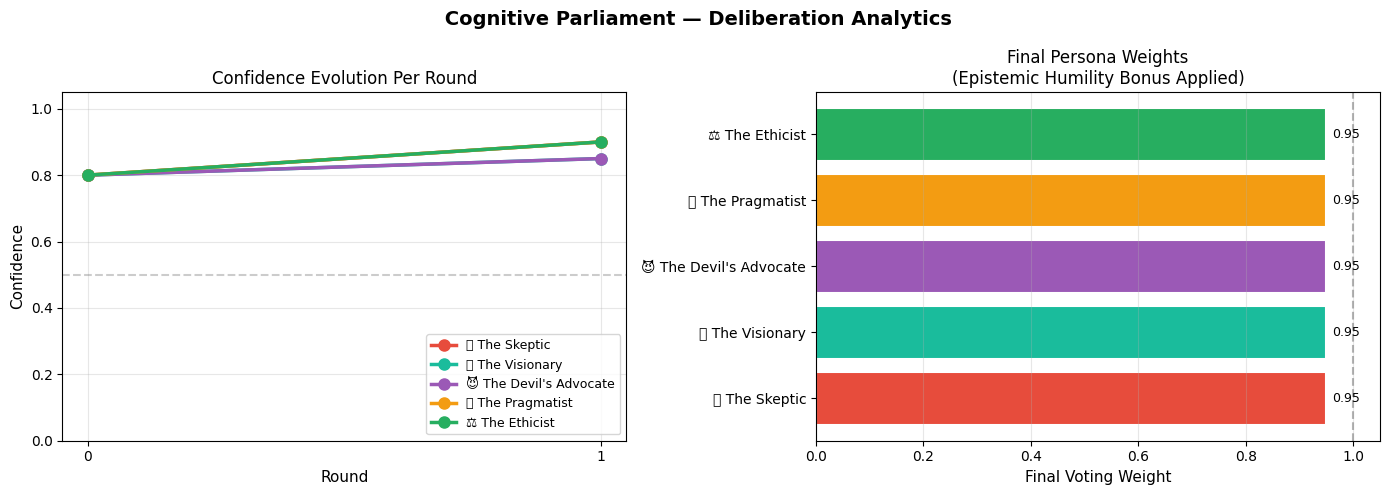

/tmp/ipykernel_1661/2143407719.py:134: UserWarning: Glyph 128376 (\N{SPIDER WEB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1661/2143407719.py:135: UserWarning: Glyph 128376 (\N{SPIDER WEB}) missing from font(s) DejaVu Sans.
  plt.savefig("parliament_influence_graph.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_1661/2143407719.py:135: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.savefig("parliament_influence_graph.png", dpi=150, bbox_inches="tight")


Chart saved to outputs/parliament_analytics.png


/tmp/ipykernel_1661/2143407719.py:135: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.savefig("parliament_influence_graph.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_1661/2143407719.py:135: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans.
  plt.savefig("parliament_influence_graph.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128376 (\N{SPIDER WEB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


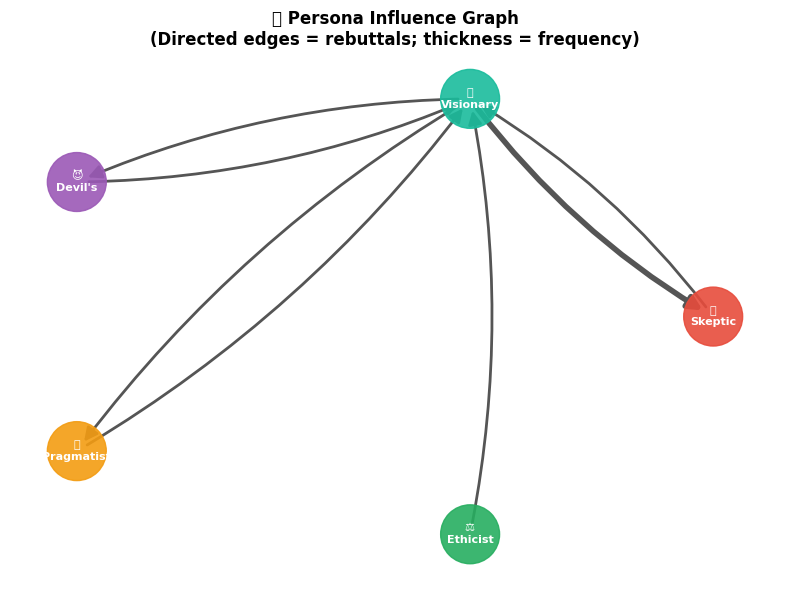

 Influence graph saved to outputs/parliament_influence_graph.png

📋 Session Summary:


,Final Stance,Confidence,Changed Mind,Final Weight
Persona,,,,
🔍 The Skeptic,AI companies should not be required by law to ...,90%,—,0.95
🚀 The Visionary,AI companies should be required to publish ful...,85%,—,0.95
😈 The Devil's Advocate,AI companies should not be required by law to ...,85%,—,0.95
🔧 The Pragmatist,AI companies should not be required by law to ...,90%,—,0.95
⚖️ The Ethicist,AI companies should not be required by law to ...,90%,—,0.95



🏆 Consensus Confidence: 92%
⚠️  Minority Report: The Visionary disagrees, advocating for required publication of full model weights with safeguards for intellectual property and security to enhance transparency and accountability.


In [14]:
"""
Render all analytics visualizations for the completed parliament session.
Charts are also saved as PNG files for inclusion in reports or GitHub README.
"""

# 1. Confidence evolution + final weights
plot_confidence_evolution(state, engine)

# 2. Persona influence graph
plot_influence_graph(state, engine)

# 3. Session summary table
print_session_summary(state, engine)

## Step 8 — Try More Queries

The parliament shines on **genuinely hard, multi-dimensional questions**. Below are ready-to-run examples.

In [15]:
"""
Additional example queries to stress-test the parliament across domains.
Uncomment any query and re-run to start a new session.

Note: Each run creates a fresh ParliamentEngine with reset weights.
"""

EXAMPLE_QUERIES = [
    # Technology & Society
    "Should universal basic income be implemented as AI automates more jobs?",

    # Science & Epistemology
    "Is scientific consensus on nutrition science trustworthy enough to base public health policy on?",

    # Agentic AI specific
    "Should autonomous AI agents be allowed to take irreversible real-world actions without human approval?",

    # Business & Ethics
    "Is it ethical for a startup to use unpaid 'alpha testers' instead of paying QA engineers?",

    # Classic dilemma
    "Is it ever justified to break a promise to prevent a larger harm?",
]

# Uncomment ONE query below and run this cell

chosen_query = EXAMPLE_QUERIES[2]  # Agentic AI specific
# chosen_query = EXAMPLE_QUERIES[0]  # UBI
# chosen_query = EXAMPLE_QUERIES[3]  # Business ethics

engine2 = ParliamentEngine(personas=PERSONAS, client=client, model=MODEL)
state2 = engine2.deliberate(query=chosen_query, num_rounds=2, verbose=True)
print_session_summary(state2, engine2)

╭────────────────────────────────────────── 🏛️ PARLIAMENT SESSION BEGINS ──────────────────────────────────────────╮
│ Should autonomous AI agents be allowed to take irreversible real-world actions without human approval?          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

============================================================

📣 OPENING STATEMENTS

============================================================

Calling 🔍 The Skeptic...

...

============================================================

╭────────────────────────────────────────── 🏆 PARLIAMENTARY CONSENSUS ───────────────────────────────────────────╮
│ Autonomous AI agents should not be allowed to take irreversible real-world actions without human approval due   │
│ to the significant risks of malfunction, lack of transparency and accountability, and insufficient              │
│ understanding of human values and ethics. Human approval provides a necessary safeguard against these risks,    │
│ ensuring accountability and moral consideration in decision-making. The potential for exacerbating existing     │
│ social inequalities by biased AI systems further supports the need for human oversight. Overall, the            │
│ precautionary approach of requiring human approval for irreversible actions aligns with ethical and moral       │
│ standards, prioritizing safety, security, and societal well-being.                                              │
│                                                                                                                 │
│ Parliament Confidence: 99%                                                                                      │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯


📋 Session Summary:


,Final Stance,Confidence,Changed Mind,Final Weight
Persona,,,,
🔍 The Skeptic,Autonomous AI agents should not be allowed to ...,95%,—,0.95
🚀 The Visionary,Autonomous AI agents should not be allowed to ...,95%,—,0.95
😈 The Devil's Advocate,Autonomous AI agents should not be allowed to ...,95%,—,0.95
🔧 The Pragmatist,Autonomous AI agents should not be allowed to ...,95%,—,0.95
⚖️ The Ethicist,Autonomous AI agents should not be allowed to ...,95%,—,0.95



🏆 Consensus Confidence: 99%


## 🛠️ Step 9 — Extensions & Ideas for Further Development

This notebook is a foundation. Here are high-value directions to take it further:

| Extension | Difficulty | Impact |
|---|---|---|
| **Persistent memory** across sessions (ChromaDB / Pinecone) | Medium | Personas remember past deliberations |
| **Tool-augmented personas** — Skeptic can web search to verify claims | Medium | Grounded, fact-checked debates |
| **Dynamic parliament composition** — query routing selects relevant personas | High | Domain-specific experts auto-selected |
| **Streaming output** with `client.messages.stream()` | Low | Real-time thinking visible to user |
| **LLM-as-judge scoring** — evaluate consensus quality vs human baseline | High | Measurable quality metric |
| **Gradio / Streamlit UI** — interactive parliament with live debate feed | Medium | Shareable web demo |
| **Multi-model parliament** — each persona runs on a different LLM | High | True model diversity |
| **Adversarial probing** — inject misleading facts to test robustness | High | AI safety research value |

---

## 📚 References & Inspiration

- [Society of Mind — Minsky (1986)](https://en.wikipedia.org/wiki/Society_of_Mind): The idea that intelligence emerges from many competing sub-agents
- [Constitutional AI — Anthropic (2022)](https://arxiv.org/abs/2212.08073): Critique-based self-improvement via structured feedback
- [Self-Consistency in Chain-of-Thought — Wang et al. (2022)](https://arxiv.org/abs/2203.11171): Ensembling multiple reasoning chains
- [AutoGen — Microsoft (2023)](https://arxiv.org/abs/2308.08155): Multi-agent conversation frameworks
- [LLM Debate — Du et al. (2023)](https://arxiv.org/abs/2305.14325): Society of agents debate improves factual accuracy

---

*Built with ❤️ using Anthropic's Claude API. Contributions welcome on GitHub.*